# Week 4: 이변량 분석 (Bivariate Analysis)

## 1. 환경 설정
분석에 필요한 라이브러리를 로드하고 데이터셋(Carseats)을 준비합니다.

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 설정
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 로드
Carseats 데이터를 로드하여 기본 구조를 확인합니다.

In [89]:
titanic = pd.read_csv('content/titanic_train.csv')
air = pd.read_csv('content/airquality2.csv')
air['Date'] = pd.to_datetime(air['Date'])

## 3. 이변량 분석: 수치형 -> 수치형
독립변수(수치형)와 종속변수(Sales) 간의 관계를 분석합니다.

Temp       0.683372
Wind      -0.605478
Solar.R    0.280068
Ozone      1.000000
Name: Ozone, dtype: float64


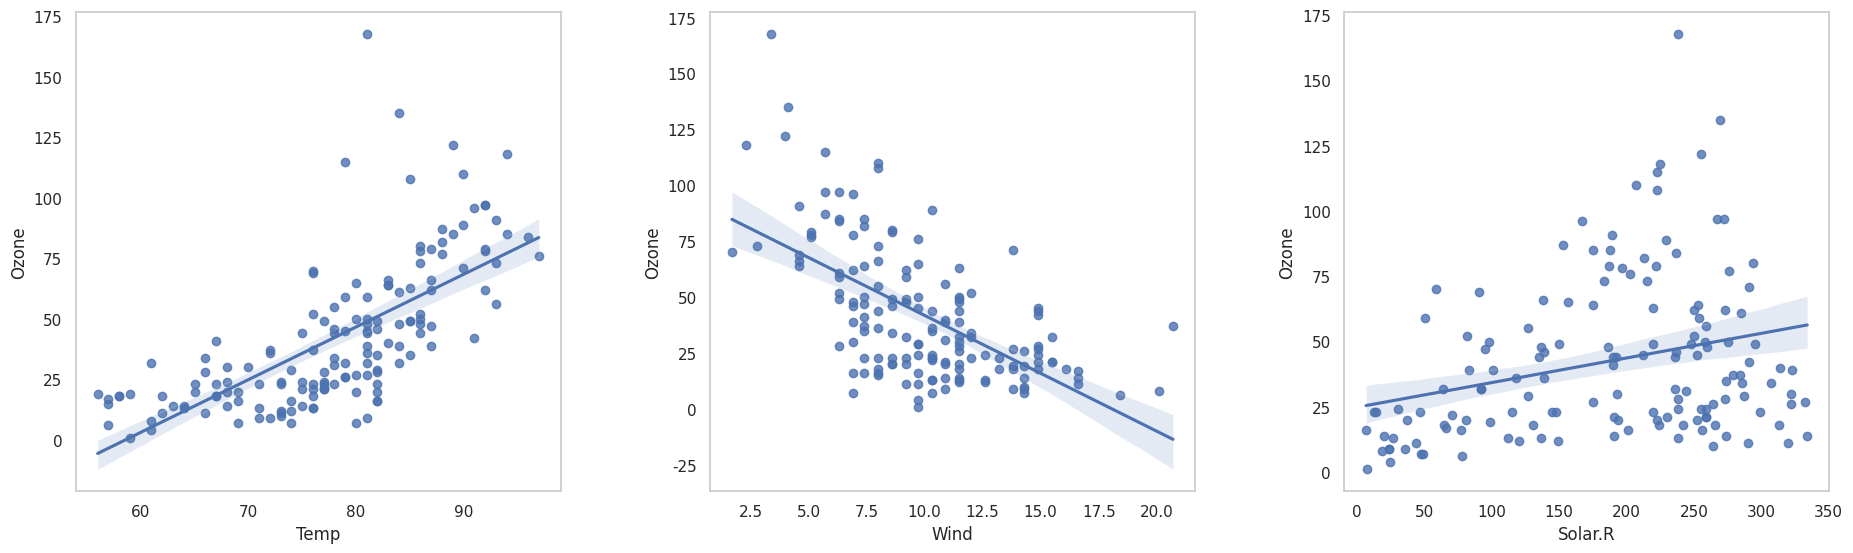

In [90]:
# 상관계수 산출 (Pearson Correlation)
correlation = air[['Temp', 'Wind', 'Solar.R', 'Ozone']].corr()
print(correlation['Ozone'])

plt.figure(figsize=(20,7))
plt.subplot(1,3,1)
# sns.scatterplot(x='Temp', y='Ozone', data=air)
sns.regplot(x='Temp', y='Ozone', data=air)
plt.grid()

plt.subplot(1,3,2)
sns.regplot(x='Wind', y='Ozone', data=air)
plt.grid()

plt.subplot(1,3,3)
sns.regplot(x='Solar.R', y='Ozone', data=air)
plt.grid()

plt.tight_layout(pad=5)
plt.show()

- 두 변수의 관계
    - 산점도에서 또렷한 패턴이 보인다면, 강한 관계로 볼 수 있다.
    - 특히, 직선의 패턴이 보인다면 강한 상관 관계를 나타낸다.
    - r 값은 상관 계수로 두 변수 간의 관계를 수치로 표현한 것이다.

**pairplot**

- pairplot으로 한꺼번에 시각화 할 수 있다.
- 숫자형 변수들에 대한 산점도를 한꺼번에 그려준다.
- 그러나 변수와 데이터가 많다면, **시간이 많이** 걸리고, 일일이 확인하기 쉽지 않다.

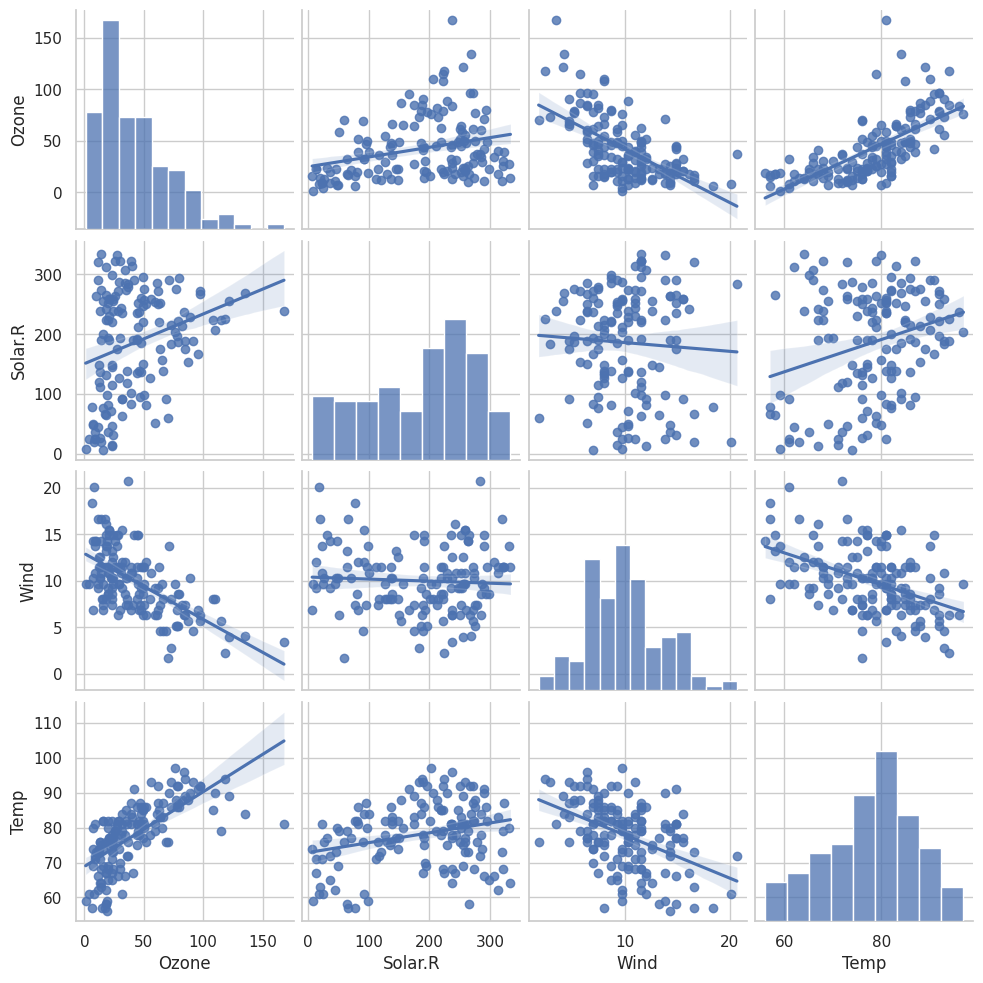

In [91]:
sns.pairplot(air, kind='reg')
plt.show()

jointplot은 산점도와 각각의 히스토그램을 함께 보여준다.

<Figure size 2000x700 with 0 Axes>

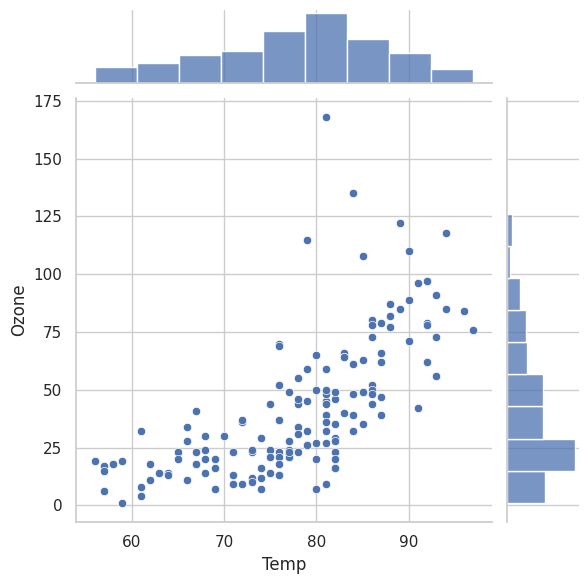

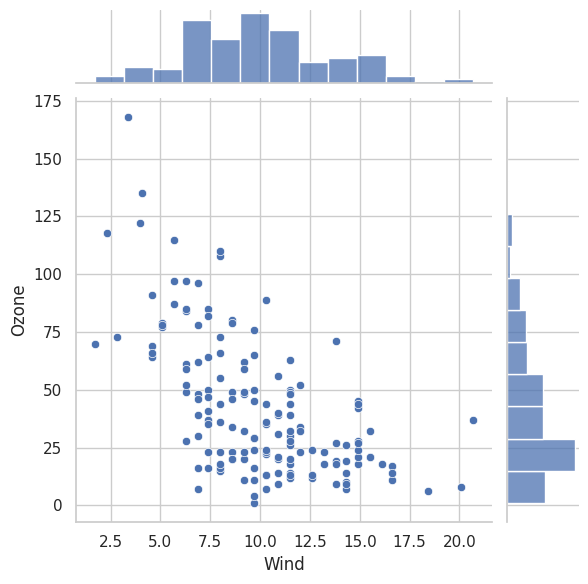

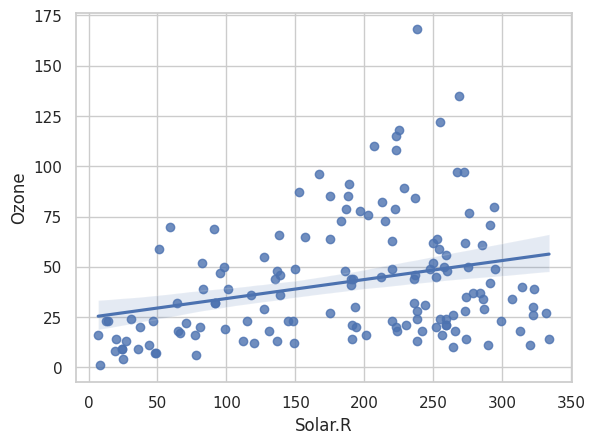

In [92]:
plt.figure(figsize=(20,7))

sns.jointplot(x='Temp', y='Ozone', data=air)
plt.show()
sns.jointplot(x='Wind', y='Ozone', data=air)

plt.show()

# 회귀선
# reg : regression
sns.regplot(x='Solar.R', y='Ozone', data=air)
plt.show()

* 상관계수 𝑟
    * 공분산을 표준화 한 값
    * -1 ~ 1 사이의 값
    * -1, 1에 가까울 수록 강한 상관관계를 나타냄.

* 경험에 의한 대략의 기준(절대적인 기준이 절대 아니다.)
    * 강한 : 0.5 < |𝑟| ≤ 1
    * 중간 : 0.2 < |𝑟| ≤ 0.5
    * 약한 : 0.1 < |𝑟| ≤ 0.2
    * (거의)없음 : |𝑟| ≤ 0.1
- p-value (유의확률): 두 변수 간의 상관관계가 우연에 의해 발생했을 확률을 의미함
- 판단 기준(유의수준)
    - p-value < 0.05: 통계적으로 유의미한 상관관계 -> 상관계수가 의미가 있다.
    - p-value ≥ 0.05: 유의미하지 않음 (즉, 우연에 의한 상관일 가능성이 높음) -> 상관계수가 의미가 없다.

- 상관계수와 p-value를 한 마디로 정리하자면:
    - 상관계수(r) : 두 변수의 관계 강도 측정
    - p-value : 그 관계가 우연이 아닐 확률 확인

In [93]:
import scipy.stats as spst

# 피어슨 상관계수와 P-value를 같이 계산
result = spst.pearsonr(air['Solar.R'].notnull(), air['Ozone'])
print(f'상관계수: {result[0]:.4f}, P-value: {result[1]:.4e}')


상관계수: 0.0483, P-value: 5.5365e-01


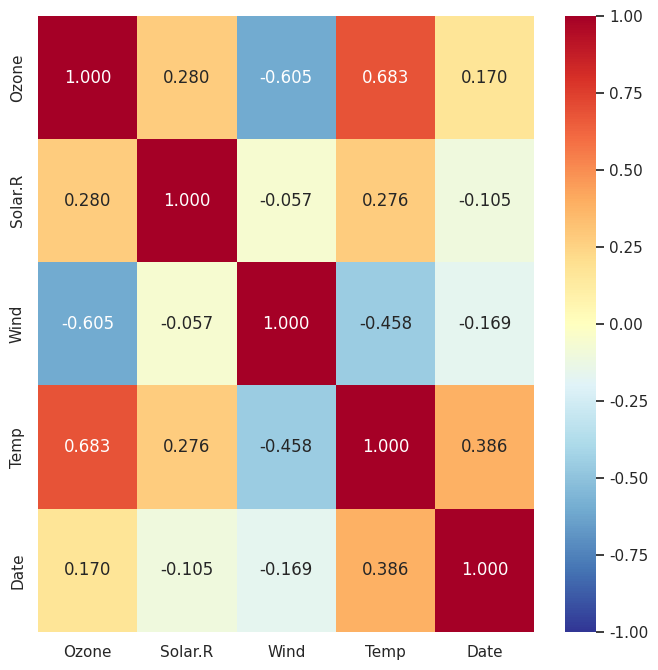

In [94]:
plt.figure(figsize=(8,8))
sns.heatmap(air.corr(),
            annot=True,         
            fmt='.3f',
            cmap='RdYlBu_r',
            vmin=-1, vmax=1)
plt.show()

  Variable  Correlation     P-value Significance
0     crim      -0.3883  1.1740e-19  Significant
1      tax      -0.4685  5.6377e-29  Significant
2    lstat      -0.7377  5.0811e-88  Significant
3  ptratio      -0.5078  1.6095e-34  Significant
4      rad      -0.3816  5.4659e-19  Significant
5     medv       1.0000  0.0000e+00  Significant


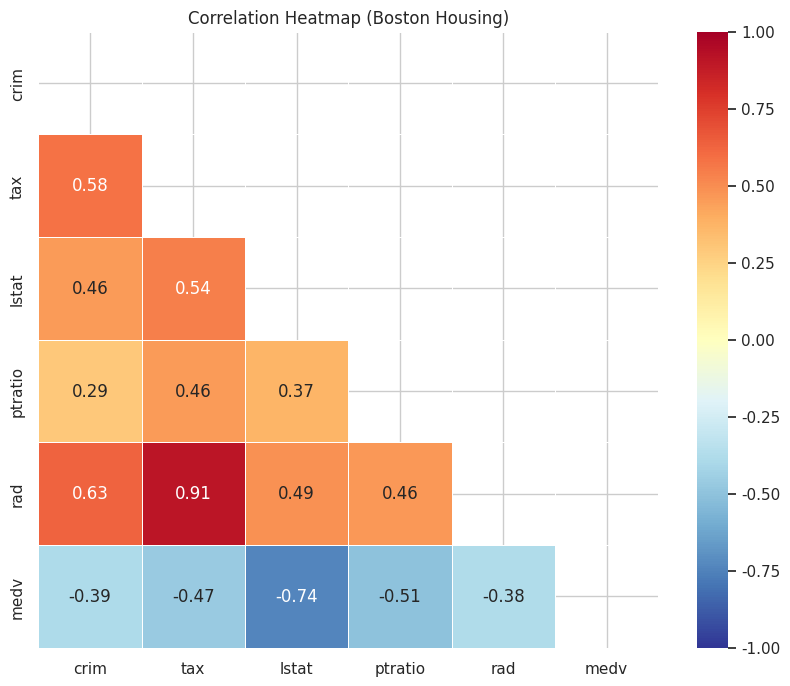

In [95]:
boston = pd.read_csv('content/boston.csv')

# 분석 대상 변수 리스트
target_cols = ['crim', 'tax', 'lstat', 'ptratio', 'rad', 'medv']

results = []
for col in target_cols:
    # 종속변수 medv와의 관계만 추출 (원하는 대상에 따라 변경 가능)
    corr, p_value = spst.pearsonr(boston[col], boston['medv'])
    results.append({
        'Variable': col,
        'Correlation': round(corr, 4),
        'P-value': format(p_value, '.4e'),
        'Significance': 'Significant' if p_value < 0.05 else 'Not Significant'
    })
# DataFrame으로 변환
analysis_df = pd.DataFrame(results)
print(analysis_df)

# 상관계수 행렬 계산
corr_matrix = boston[target_cols].corr()
# 상삼각 행렬 마스크 생성 (대칭되는 위쪽을 가림)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,            # 숫자 표시
            fmt=".2f",             # 소수점 둘째 자리까지
            mask=mask,             # 마스크 적용
            cmap='RdYlBu_r',       # 빨강(음)-노랑-파랑(양) 컬러맵
            vmin=-1, vmax=1,       # 범위 고정
            center=0,              # 중앙값 0
            linewidths=.5)         # 칸 사이 간격
plt.title('Correlation Heatmap (Boston Housing)')
plt.show()

- crim: 관계는 확실하나 영향력이 높지 않다.
- tax: 매우 관계가 있고 고려할 가치가 있다.
- lstat: 매우 관계가 있고 영향력도 높다
- ptratio: 관계가 확실하고 고려할 가치도 있다.

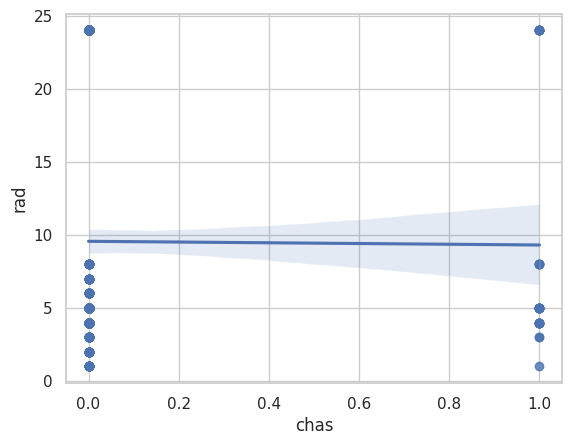

In [96]:
sns.regplot(x='chas', y='rad', data=boston)
plt.show()

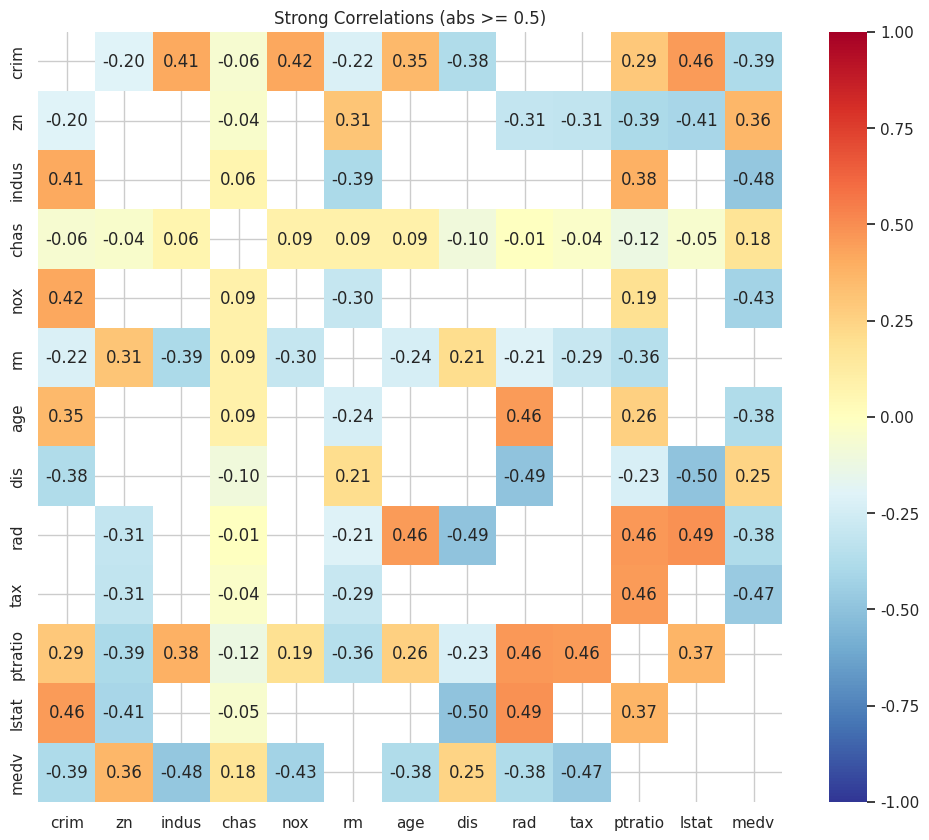

In [97]:
corr = boston.corr()
# 절대값이 0.5 이상인 것만 남기고 나머지는 NaN 처리
cond = (corr.abs() < 0.5) & (corr != 1.0) # 자기 자신(1.0) 제외
strong_corr = corr[cond]
plt.figure(figsize=(12, 10))
sns.heatmap(strong_corr, 
            annot=True, fmt=".2f", 
            cmap='RdYlBu_r', 
            vmin=-1, vmax=1, center=0)
plt.title('Strong Correlations (abs >= 0.5)')
plt.show()

          Survived       Age
Survived  1.000000 -0.077221
Age      -0.077221  1.000000


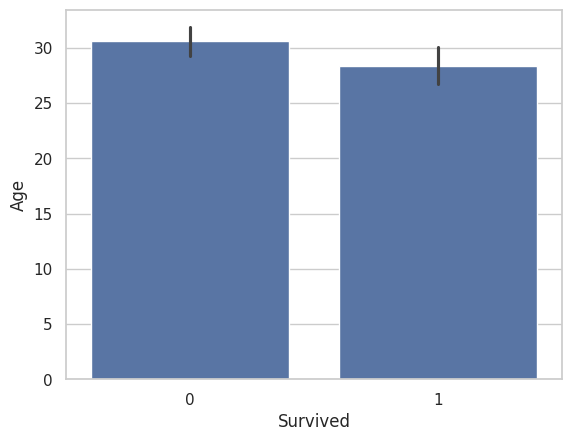

In [98]:
sns.barplot(x='Survived', y='Age', data=titanic)

print(titanic[['Survived', 'Age']].corr())

plt.show()

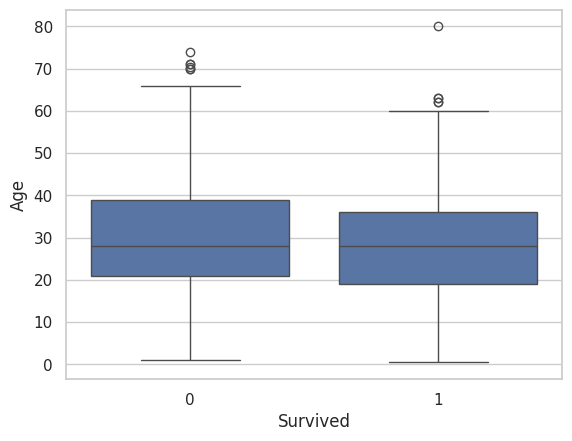

In [99]:
sns.boxplot(x='Survived', y='Age', data=titanic)
plt.show()

- 두 집단의 평균 비교
    - 예제는 Two sample T-test와 양측검정만 다룬다.
    - 우리는 X --> Y의 관계에서 ,두 변수간에 관련이(차이가) 있는지, 없는지를 확인하는 것이 제일 중요하기 때문이다.

- 주의사항 : 데이터에 NaN이 있으면 계산이 안된다. `.notnull()` 등으로 NaN을 제외한 데이터를 사용해야 한다.

- t 통계량(t-statistic)
    - 두 집단의 평균 차이를 표준오차로 나눈 값
    - 기본적으로는 두 평균의 차이로 이해해도 좋다.
    - 우리의 가설(대립가설)은 차이가 있다는 것이므로, t 값이 크던지 작던지 하기를 바란다.
    - 보통, t 값이 -2보다 작거나, 2보다 크면 차이가 있다고 본다.

In [100]:
# NaN 행 제외
temp = titanic.loc[titanic['Age'].notnull()]

# 두 그룹으로 데이터 저장
died = temp.loc[temp['Survived']==0, 'Age']
survived = temp.loc[temp['Survived']==1, 'Age']

t_stat, p_val = spst.ttest_ind(died, survived)

print("="*40)
print(f" T-statistic : {t_stat:.4f}")
print(f" P-value     : {p_val:.4e}") # 지수 표기법
print("-"*40)
if p_val < 0.05:
    print(" 결과: 통계적으로 유의미한 차이가 있음 (p < 0.05)")
else:
    print(" 결과: 통계적으로 유의미한 차이가 없음 (p >= 0.05)")
print("="*40)


 T-statistic : 2.0667
 P-value     : 3.9125e-02
----------------------------------------
 결과: 통계적으로 유의미한 차이가 있음 (p < 0.05)


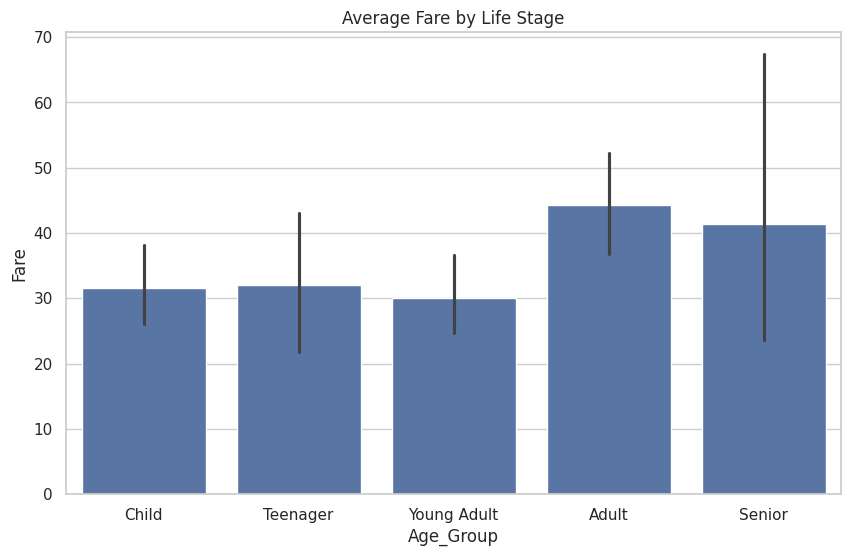

In [101]:
# 구간 정의: 0~12(아이), 12~19(청소년), 19~35(청년), 35~60(중년), 60~100(노년)
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
titanic['Age_Group'] = pd.cut(titanic['Age'], bins=bins, labels=labels)
plt.figure(figsize=(10, 6))
sns.barplot(x='Age_Group', y='Fare', data=titanic)
plt.title('Average Fare by Life Stage')
plt.show()

In [102]:
# 두 그룹 데이터 추출
group_child = titanic.loc[titanic['Age_Group'] == 'Child', 'Fare']
group_senior = titanic.loc[titanic['Age_Group'] == 'Senior', 'Fare']

# T-test 실행
t_stat, p_val = spst.ttest_ind(group_child, group_senior)
print(f"Child vs Senior P-value: {p_val:.4f}")


Child vs Senior P-value: 0.2574


In [103]:
# 각 그룹별로 데이터를 리스트에 담기
# NaN값은 제거하고 진행해야 합니다.
groups = [titanic.loc[titanic['Age_Group'] == label, 'Fare'].dropna() 
          for label in titanic['Age_Group'].dropna().unique()]

# ANOVA 실행 (f_oneway)
f_stat, p_val = spst.f_oneway(*groups)

print("="*40)
print(f" ANOVA P-value: {p_val:.4f}")
print("="*40)

if p_val < 0.05:
    print(" 결과: 나이대 그룹별로 운임(Fare)의 평균 차이가 확실히 있습니다! ✅")
else:
    print(" 결과: 나이대별로 운임의 유의미한 차이가 없다고 판단됩니다. ❌")


 ANOVA P-value: 0.0444
 결과: 나이대 그룹별로 운임(Fare)의 평균 차이가 확실히 있습니다! ✅


- 분산 분석 **AN**alysis **O**f **VA**riance
    - **ANOVA (Analysis of Variance)** 는 셋 이상 집단의 평균 차이가 통계적으로 유의미한지를 검정하는 방법
    - 여러 집단 간에 차이는 어떻게 비교할 수 있을까?
    - 여기서 기준은 **전체 평균** 이다.
- f분포
    - 두 개의 독립된 정규분포를 따르는 모집단의 분산 비율로 만들어지는 확률 분포
    - 오른쪽으로 길게 늘어진 비대칭 분포를 가지며, 0에서 시작해서 무한대로 이어짐
    - 값이 대략 2~3 이상이면 차이가 있다고 판단한다.

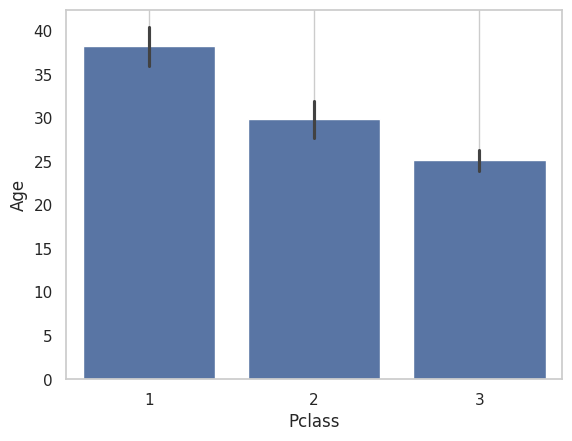

In [104]:
# Pclass(3 범주) -> Age
sns.barplot(x='Pclass', y='Age', data=titanic)
plt.grid()
plt.show()

In [126]:
# 분산 분석을 위한 데이터를 만들기
# NaN 행 제외
temp = titanic.loc[titanic['Age'].notnull()]

# 그룹별 저장
# 각 그룹(=집단)의 분포를 따로 분리해서 비교하기 위함
p_1 = temp.loc[temp['Pclass']==1, 'Age']
p_2 = temp.loc[temp['Pclass']==2, 'Age']
p_3 = temp.loc[temp['Pclass']==3, 'Age']

# ANOVA 실행 (f_oneway)
f_stat, p_val = spst.f_oneway(p_1, p_2, p_3)

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.3e}")
print("="*40)

 ANOVA F-stat: 57.4435
 ANOVA P-value: 7.488e-24


 ANOVA F-stat: 0.7671
 ANOVA P-value: 0.444191


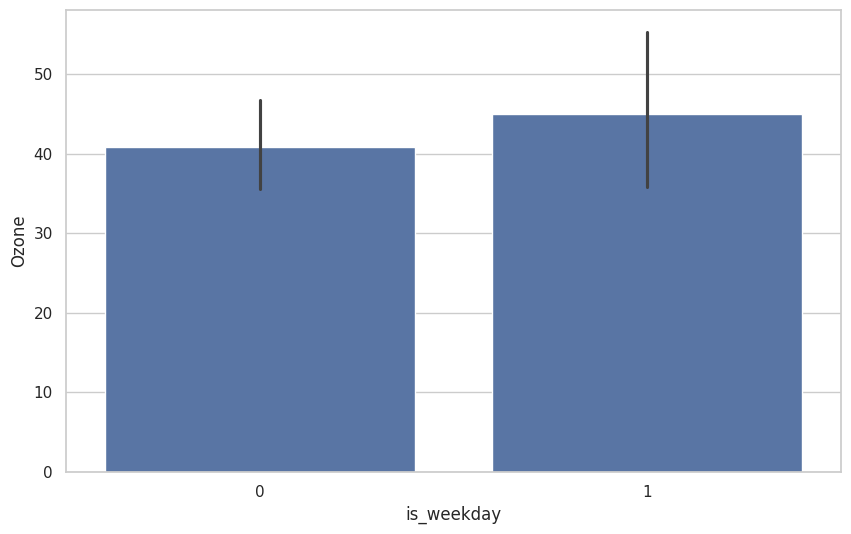

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Ozone       153 non-null    int64         
 1   Solar.R     146 non-null    float64       
 2   Wind        153 non-null    float64       
 3   Temp        153 non-null    int64         
 4   Date        153 non-null    datetime64[us]
 5   is_weekday  153 non-null    int64         
dtypes: datetime64[us](1), float64(2), int64(3)
memory usage: 7.3 KB


In [165]:
air = pd.read_csv('content/airquality2.csv')
air['Date'] = pd.to_datetime(air['Date'])
air['is_weekday'] = air['Date'].dt.dayofweek.isin([5, 6]).astype(int)


f_stat, p_val = spst.ttest_ind(*[air.loc[air['is_weekday'] == i, 'Ozone'] for i in [True, False]])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.6f}")

plt.figure(figsize=(10, 6))
sns.barplot(x=air['is_weekday'], y=air['Ozone'])
plt.show()

 ANOVA F-stat: 0.5099
 ANOVA P-value: 0.80014


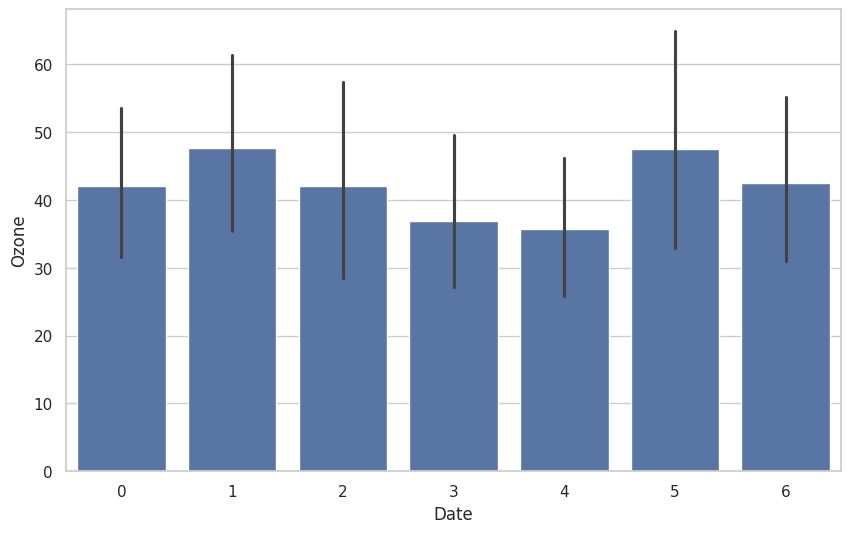

In [163]:
f_stat, p_val = spst.f_oneway(*[air.loc[air['Date'].dt.day_of_week == i, 'Ozone'] for i in range(0,7)])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5f}")

plt.figure(figsize=(10, 6))
sns.barplot(x=air['Date'].dt.weekday, y=air['Ozone'])
plt.show()

 ANOVA F-stat: 10.7030
 ANOVA P-value: 0.000000


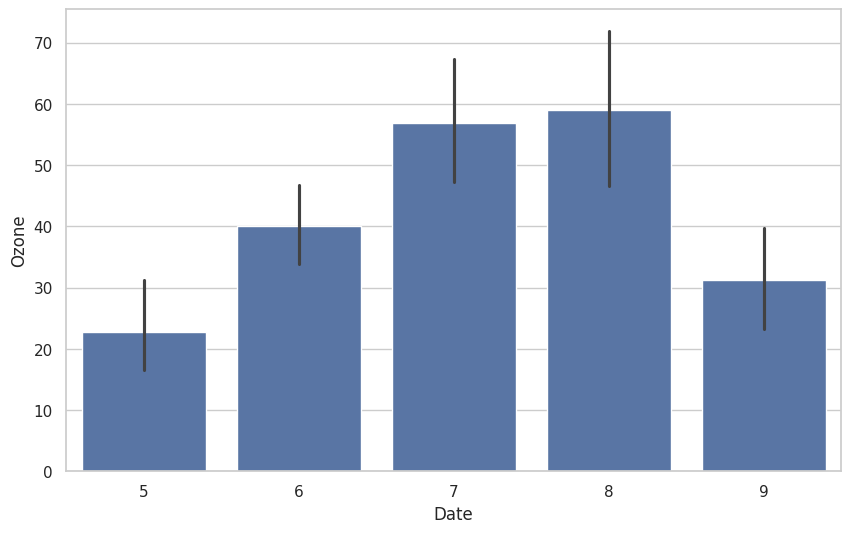

In [164]:
f_stat, p_val = spst.f_oneway(*[air.loc[air['Date'].dt.month == i, 'Ozone'] for i in air['Date'].dt.month.unique()])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.6f}")

plt.figure(figsize=(10, 6))
sns.barplot(x=air['Date'].dt.month, y=air['Ozone'])
plt.show()

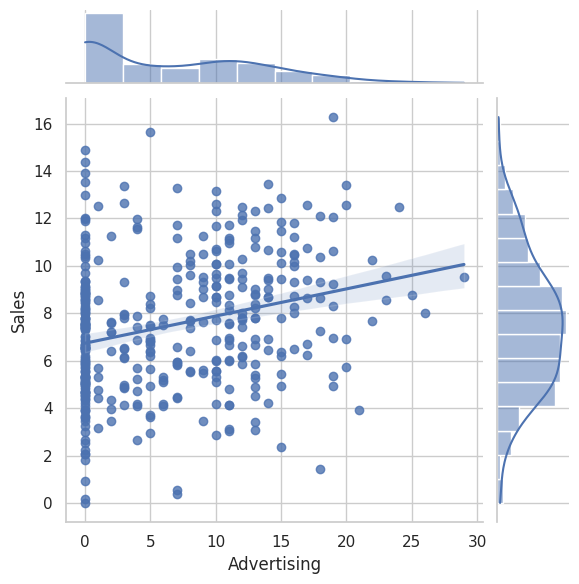

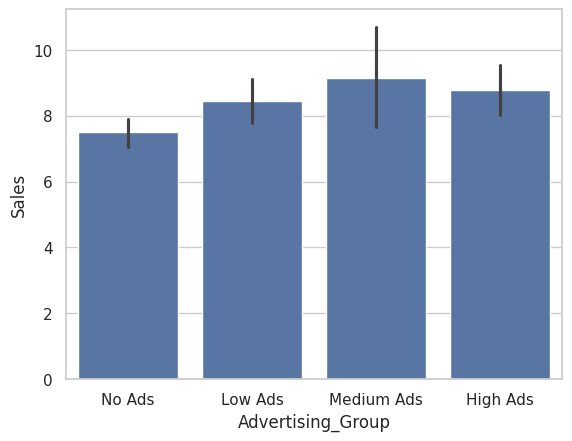

 ANOVA F-stat: 3.3785
 ANOVA P-value: 0.01894
PearsonRResult(statistic=np.float64(0.2571829256169392), pvalue=np.float64(3.112672883086026e-05))


In [229]:
car = pd.read_csv('content/Carseats.csv')

bins = [0, 12, 18, 24, 30]
labels = ['No Ads', 'Low Ads', 'Medium Ads', 'High Ads']
car['Advertising_Group'] = pd.cut(car['Advertising'], bins=bins, labels=labels)

sns.jointplot(x='Advertising', y='Sales', data=car, kind='reg')
plt.show()
sns.barplot(x='Advertising_Group', y='Sales', data=car, )
plt.show()

f_stat, p_val = spst.f_oneway(*[car.loc[car['Advertising_Group'] == i, 'Sales'] for i in labels])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5f}")


print(spst.pearsonr(car.loc[car['Advertising'] != 0]['Advertising'], car.loc[car['Advertising'] != 0]['Sales']))

- 파악한 내용
    - 바 차트 상 금액대 별로 유의미해 보임(p-value도 1퍼)
    - 하지만 산점도와 히스토그램 상 광고 없이도 판매량이 다양하기 때문에 확신 불가
    - f-stat도 3점대로 큰 영향이 없음

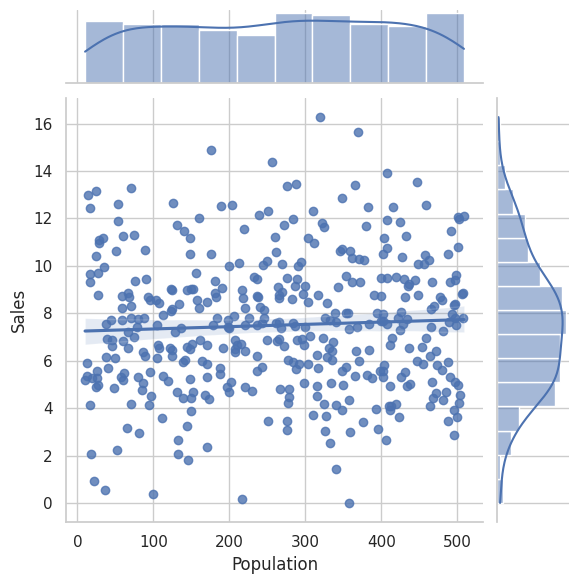

 ANOVA F-stat: 0.0505
 ANOVA P-value: 0.31398


In [197]:
sns.jointplot(x='Population', y='Sales', data=car, kind='reg')
plt.show()

f_stat, p_val = spst.pearsonr(x=car['Population'], y=car['Sales'])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5f}")

- 파악한 내용
    - 그래프 수치 모두 판매량과 관계가 없음

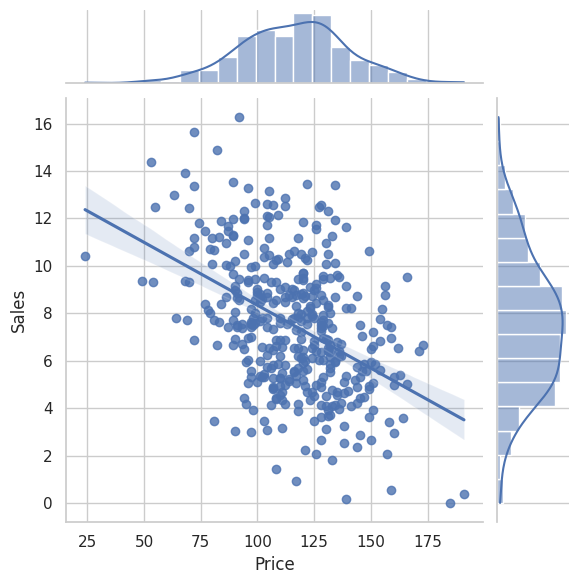

 ANOVA F-stat: -0.4450
 ANOVA P-value: 7.61819e-21


In [199]:
sns.jointplot(x='Price', y='Sales', data=car, kind='reg')
plt.show()

f_stat, p_val = spst.pearsonr(x=car['Price'], y=car['Sales'])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5e}")

- 파악한 내용
    - 가격이 높을수록 회귀선이 우하향하고 있음
    - 신뢰구간이 벌어지긴하지만 가격 측정에 따라 판매량은 유의미하게 변화함
    - 0에 가까운 p벨류와 f-stat -0.4가 이를 증명

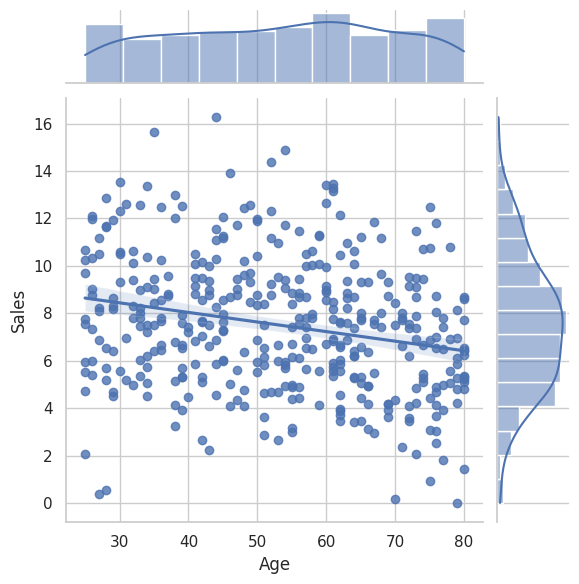

 ANOVA F-stat: -0.2318
 ANOVA P-value: 2.78895e-06


In [202]:
sns.jointplot(x='Age', y='Sales', data=car, kind='reg')
plt.show()

f_stat, p_val = spst.pearsonr(x=car['Age'], y=car['Sales'])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5e}")

- 파악한 내용
    - 적은 변화지만 30대 전후로 판매량이 좀 더 높음
    - 하지만 수요자체는 노년층이 다수
    - 관계가 있지만(p-value) 연관관계는 낮음(f-stat)

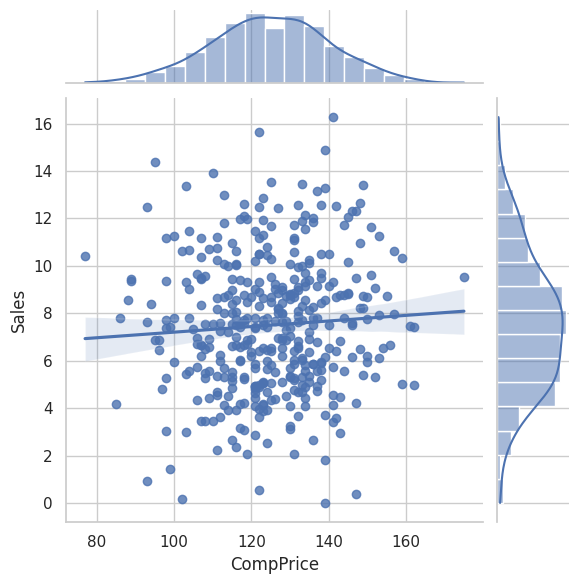

 ANOVA F-stat: 0.0641
 ANOVA P-value: 2.00940e-01


In [204]:
sns.jointplot(x='CompPrice', y='Sales', data=car, kind='reg')
plt.show()

f_stat, p_val = spst.pearsonr(x=car['CompPrice'], y=car['Sales'])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5e}")

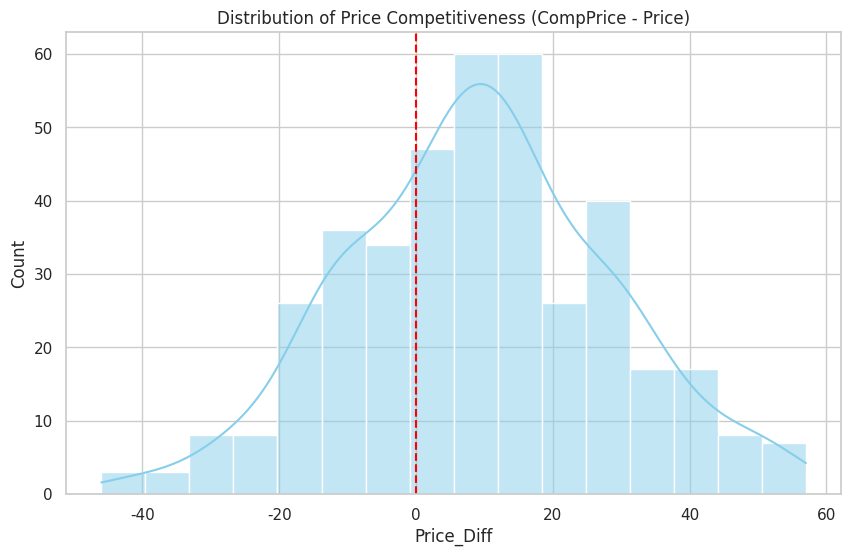

 ANOVA r: 0.5979
 ANOVA P-value: 3.87712e-40


In [231]:
# 경쟁사보다 우리가 얼마나 싼지를 나타내는 지표 (양수면 우리가 저렴함)
car['Price_Diff'] = car['CompPrice'] - car['Price']

plt.figure(figsize=(10, 6))
# 0을 기준으로 우리가 비싼지 싼지 분포 확인
sns.histplot(car['Price_Diff'], kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--') # 0 지점에 기준선 추가
plt.title('Distribution of Price Competitiveness (CompPrice - Price)')
plt.show()


f_stat, p_val = spst.pearsonr(x=car['Price_Diff'], y=car['Sales'])

print("="*40)
print(f" ANOVA r: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5e}")

- 파악한 내용
    - 영향력이 적음

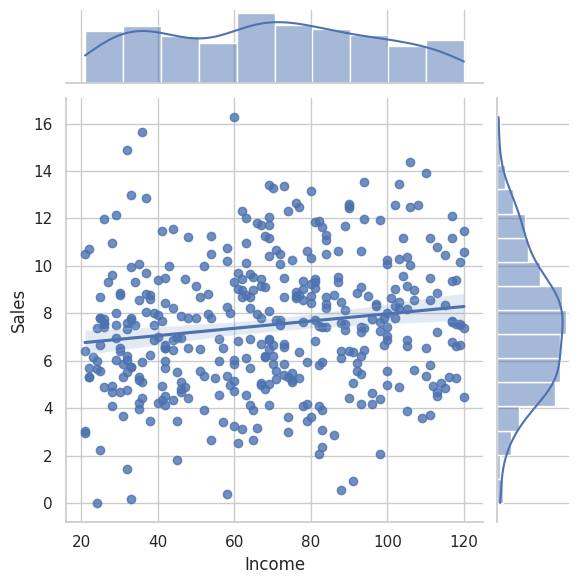

 ANOVA F-stat: 0.1520
 ANOVA P-value: 2.30967e-03


In [205]:
sns.jointplot(x='Income', y='Sales', data=car, kind='reg')
plt.show()

f_stat, p_val = spst.pearsonr(x=car['Income'], y=car['Sales'])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5e}")

- 파악한 내용
    - 역시 가치없어보임

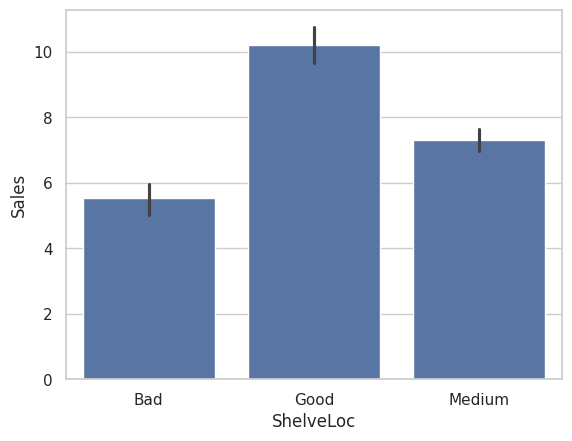

 ANOVA F-stat: 92.2299
 ANOVA P-value: 1.26694e-33


In [208]:
sns.barplot(x='ShelveLoc', y='Sales', data=car)
plt.show()

f_stat, p_val = spst.f_oneway(*[car.loc[car['ShelveLoc'] == i, 'Sales'] for i in car['ShelveLoc'].unique()])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5e}")

- 파악한 내용
    - 진열 위치별로 판매량이 유의미하게 차이남
    - 수치도 f-stat이 92로 굉장히 높음 p-value도 0에 가까움
    - 기타 어떤 수치보다도 우선으로 진열방식의 개선이 필요해보임

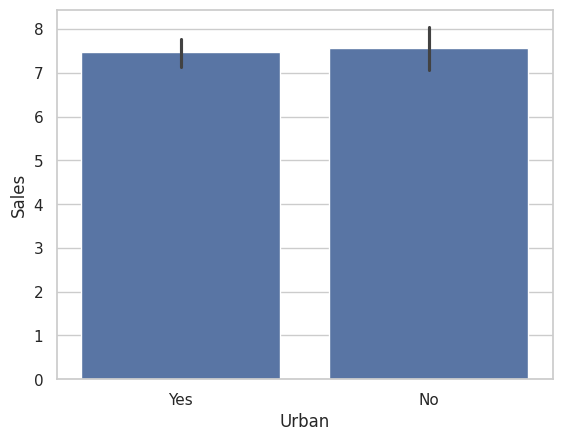

 ANOVA F-stat: 0.0947
 ANOVA P-value: 7.58507e-01


In [210]:
sns.barplot(x='Urban', y='Sales', data=car)
plt.show()

f_stat, p_val = spst.f_oneway(*[car.loc[car['Urban'] == i, 'Sales'] for i in car['Urban'].unique()])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5e}")

- 파악한 내용
    - 무의미함

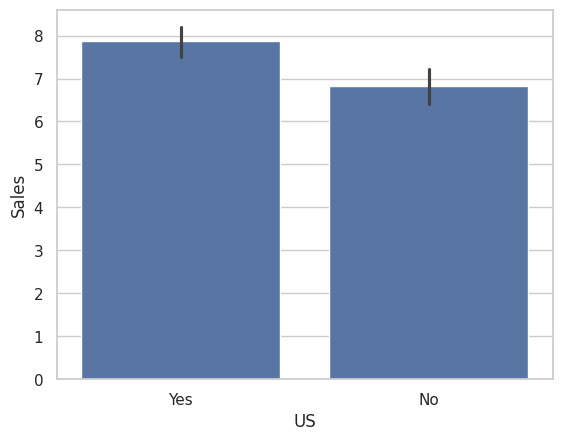

 ANOVA F-stat: 12.8862
 ANOVA P-value: 3.72340e-04


In [211]:
sns.barplot(x='US', y='Sales', data=car)
plt.show()

f_stat, p_val = spst.f_oneway(*[car.loc[car['US'] == i, 'Sales'] for i in car['US'].unique()])

print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5e}")

- 파악한 내용
    - 어느정도 영향이 있음
    - Urban과 엮어서 볼 필요성도 느낌, 미국 도심의 판매량을 분석해보면 좋을 듯
    - 인구, 수입, 연령 같은 그 지역의 데이터와 엮어봐도 좋을 듯함

- 강한 관계
    - Shelveloc, Price
- 중간 관계
    - US, Advertising

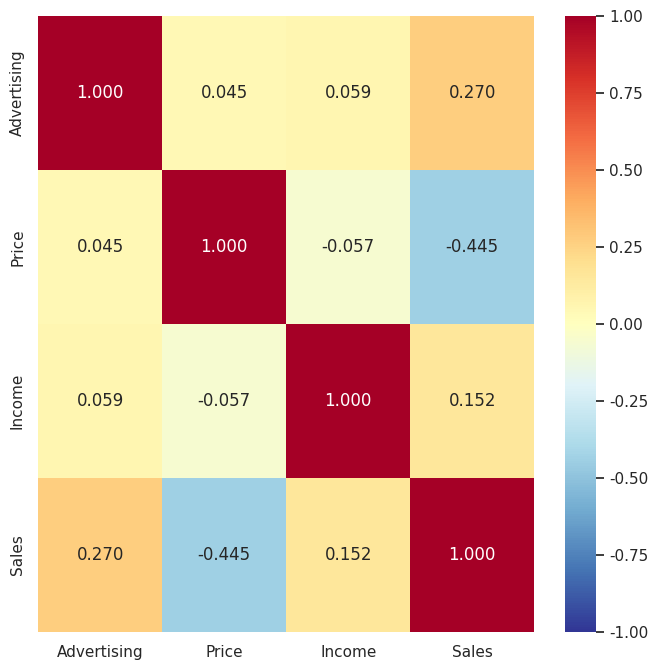

 ANOVA F-stat: 1.4189
 ANOVA P-value: 0.15670


In [223]:
plt.figure(figsize=(8,8))
sns.heatmap(car[['Advertising', 'Price', 'Income','Sales']].corr(),
            annot=True,         
            fmt='.3f',
            cmap='RdYlBu_r',
            vmin=-1, vmax=1)
plt.show()

urban_us_car = car.query("Urban == 'Yes' and US == 'Yes'")
not_urban_us_car = car.query("Urban != 'Yes' or US != 'Yes'")

f_stat, p_val = spst.ttest_ind(urban_us_car['Sales'], not_urban_us_car['Sales'])


print("="*40)
print(f" ANOVA F-stat: {f_stat:.4f}")
print(f" ANOVA P-value: {p_val:.5f}")